In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import helpers
from sklearn.impute import KNNImputer 
from sklearn.preprocessing import StandardScaler
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

In [2]:
train = train.copy()

In [3]:
train.sample(10)

,sensor,time,power,temperature
3656955,N706,4.971110e+09,0.000000,17.614079
284680,N208,1.479254e+09,790.093384,36.388920
4310033,N917,1.397174e+09,1000.000000,50.676197
4407073,N928,6.371827e+09,0.000000,5.042912
3069963,N441,2.552515e+09,1500.000000,37.350216
4013785,N847,5.695229e+09,0.000000,7.125897
6308961,N89,1.307318e+09,1400.000000,18.153023
3665694,N708,4.635792e+09,500.000000,21.739576
2938358,N369,7.143466e+09,0.000000,8.873539
2042268,N907,5.808413e+09,353.950836,18.978519


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   sensor       category
 1   time         float64 
 2   power        float32 
 3   temperature  float32 
dtypes: category(1), float32(2), float64(1)
memory usage: 113.8 MB


In [5]:
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [6]:
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [7]:
train["temperature"] = train["temperature"].fillna(train["temperature"].mean()) #ici à la place de prendre le mean de tout, il faudrait prendre celui des 3-4 sensor les plus proches --> KNN

In [8]:
train.isna().any() #control qu'on ai bien rempli toutes les missing values

sensor         False
time           False
power          False
temperature    False
dtype: bool

In [9]:
# Enlever les outliers
train = train[train['temperature'] > -200]
train = train[train['temperature'] < 6000]

# Vérification
print(train['temperature'].min(), train['temperature'].max())
print(train.shape)

-119.05078 186.7141
(6572160, 4)


In [10]:
print("NaN avant KNN:", train['temperature'].isna().sum())

NaN avant KNN: 0


In [11]:

# Fusionner les coordonnées des sensors
train_with_coords = train.merge(sensors[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor')

imputer = KNNImputer(n_neighbors=4)
train_with_coords['temperature'] = imputer.fit_transform(
    train_with_coords[['temperature', 'coor_x', 'coor_y', 'coor_z']]
)[:, 0]

In [12]:
print("NaN après KNN:", train_with_coords['temperature'].isna().sum())
print("Min température:", train_with_coords['temperature'].min())
print("Max température:", train_with_coords['temperature'].max())
print(train_with_coords[train_with_coords['temperature'] < 0])

NaN après KNN: 0
Min température: -119.05078
Max température: 186.7141
        sensor          time        power  temperature     coor_x    coor_y  \
9161      N103  2.851200e+07  1465.658569   -47.918625  45.198502  3.500000   
9366      N103  2.056320e+08  1339.613770   -14.135831  45.198502  3.500000   
9383      N103  2.203200e+08  1329.924316   -38.494190  45.198502  3.500000   
9426      N103  2.574720e+08  1306.063599   -25.373438  45.198502  3.500000   
9577      N103  3.879360e+08  1227.375977   -54.551613  45.198502  3.500000   
...        ...           ...          ...          ...        ...       ...   
6552799   N926  6.929971e+09     0.000000   -82.178413   1.177973  2.991269   
6552932   N926  7.044883e+09     0.000000   -68.515434   1.177973  2.991269   
6553330   N926  7.388842e+09     0.000000   -75.217758   1.177973  2.991269   
6553519   N926  7.552138e+09     0.000000   -37.372665   1.177973  2.991269   
6553718   N926  7.724074e+09     0.000000   -52.302612   1.1

In [ ]:
# Normalisation
scaler = StandardScaler()
train_with_coords[['time', 'power']] = scaler.fit_transform(
    train_with_coords[['time', 'power']]
)

# Vérification
print(train_with_coords[['time', 'power']].describe())

               time         power
count  6.572160e+06  6.572160e+06
mean   7.306779e-17 -8.247803e-17
std    1.000000e+00  1.000000e+00
min   -1.732045e+00 -1.055347e+00
25%   -8.657853e-01 -1.055347e+00
50%    1.327983e-04 -2.098822e-01
75%    8.660130e-01  8.463630e-01
max    1.731931e+00  1.797218e+00


In [14]:
train = pd.get_dummies(train) #one-hot-encoding

In [15]:
train.sample(10)

,time,power,temperature,sensor_N102,sensor_N103,sensor_N108,sensor_N112,sensor_N113,sensor_N12,sensor_N121,...,sensor_N920,sensor_N921,sensor_N922,sensor_N923,sensor_N924,sensor_N925,sensor_N926,sensor_N927,sensor_N928,sensor_N96
167053,2.374531e+09,605.428162,29.232191,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5395376,6.289920e+08,1400.000000,18.799217,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5570089,1.735949e+09,1400.000000,35.721569,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
973194,4.859654e+09,391.433685,19.685860,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4079981,7.681738e+09,0.000000,13.389483,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1594067,5.005670e+09,384.693207,19.332424,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1156342,5.367686e+09,369.587128,17.683741,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
873738,5.682269e+09,358.426239,18.024561,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2180401,6.855667e+09,322.774445,16.608807,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4445793,3.948480e+08,1400.000000,17.994936,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<Axes: xlabel='coor_x', ylabel='coor_y'>

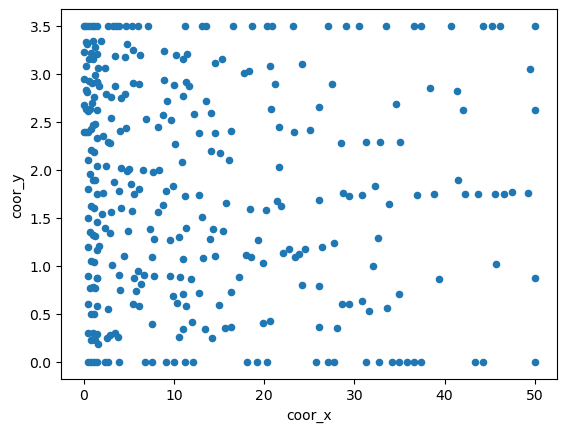

In [16]:
sensors.plot(kind='scatter', x='coor_x', y='coor_y')

<Axes: xlabel='time', ylabel='power'>

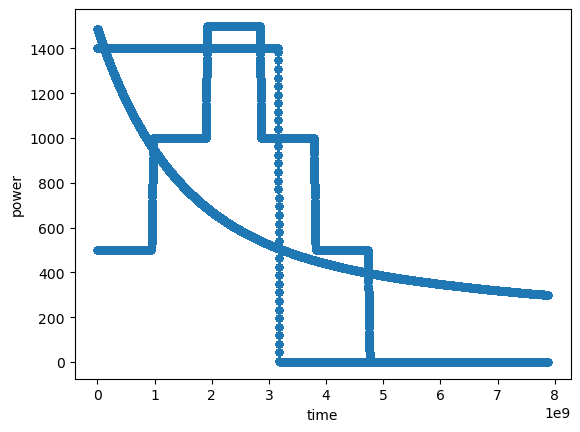

In [17]:
train.plot(kind='scatter', x='time', y='power')

(2190720, 245) (2190720, 245) (2190720, 245)


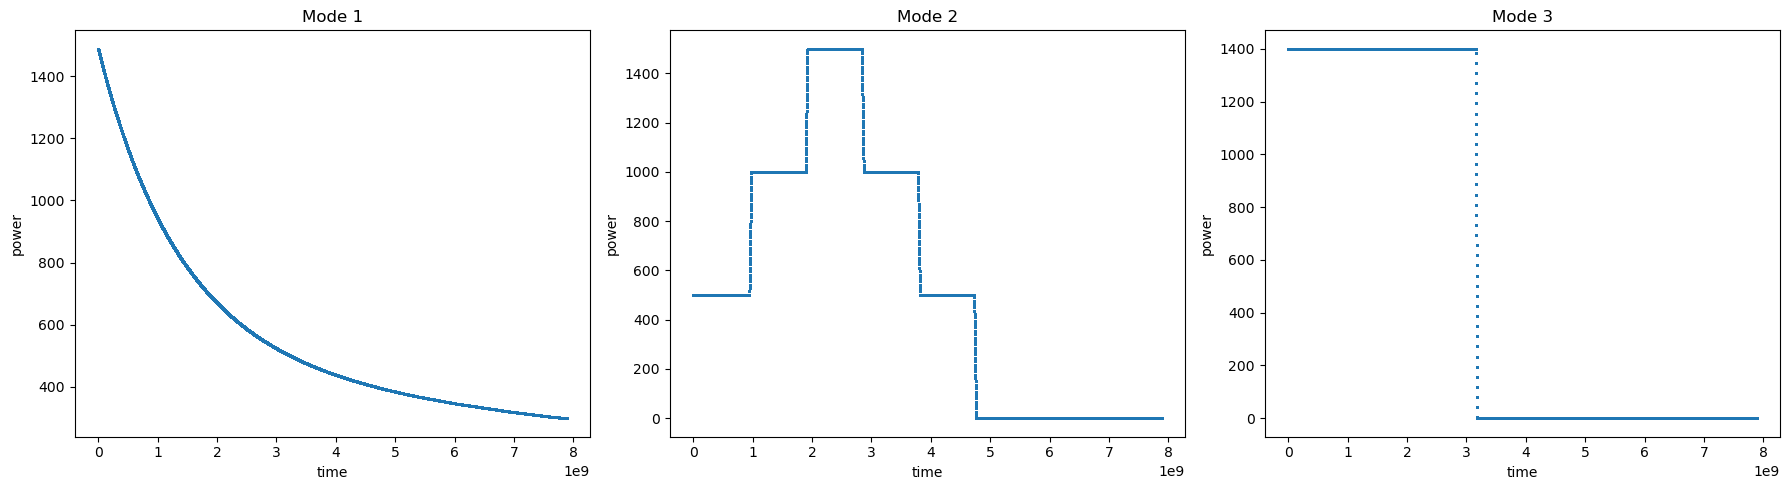

In [18]:
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

# Vérification
print(mode1.shape, mode2.shape, mode3.shape)

# Visualiser les 3 modes séparément
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()


<Axes: xlabel='time', ylabel='temperature'>

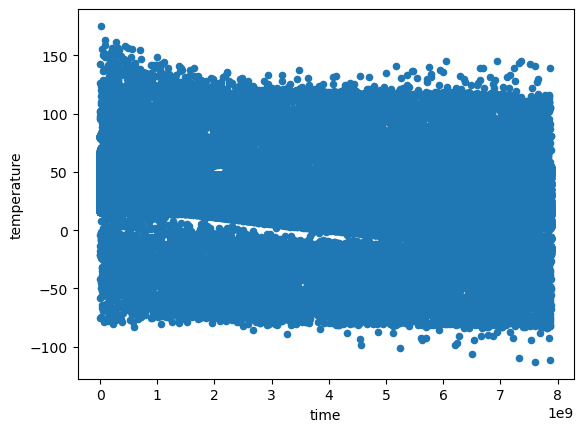

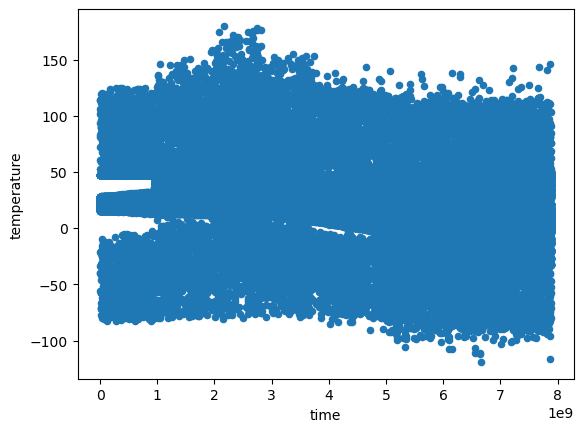

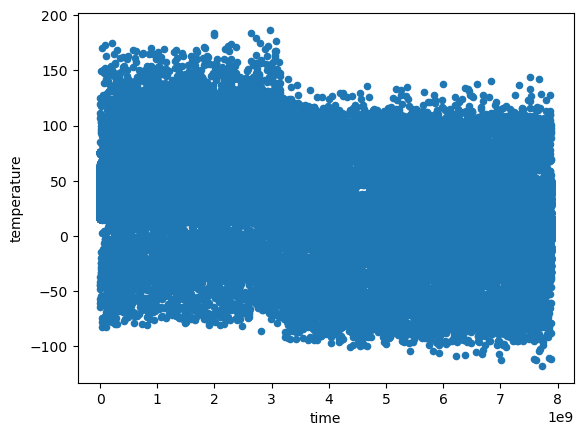

In [19]:
mode1.plot(kind='scatter', x='time', y='temperature')
mode2.plot(kind='scatter', x='time', y='temperature')
mode3.plot(kind='scatter', x='time', y='temperature')

<Axes: xlabel='time', ylabel='temperature'>

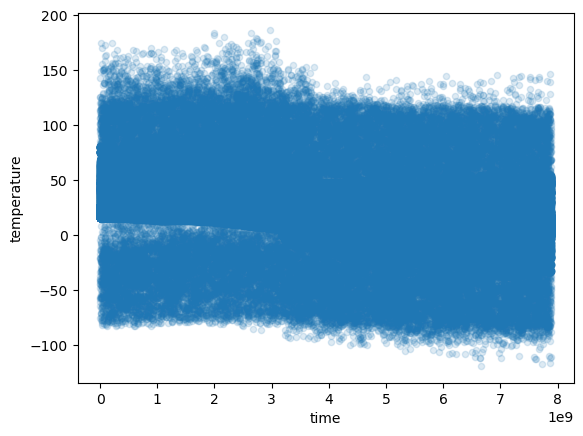

In [20]:
train.plot(kind='scatter', x='time', y='temperature', alpha=0.15)

In [ ]:
X_train, y_train, X_test, y_test, feature_names = helpers.preprocess_data(train, label="temperature", train_size=0.8, seed=42)

In [ ]:

def add_constant(X: np.ndarray) -> np.ndarray:
    """ Adds an constant term to the dataset (as the first column)

    Args:
        X (np.ndarray): Dataset of shape (N, D-1)

    Returns: 
        Dataset with offset term added, of shape (N, D)

    """
    X_with_offset = np.insert(X, 0, 1, axis=1)

    return X_with_offset

X_train = add_constant(X_train)
X_test = add_constant(X_test)

In [ ]:
print('Training set features:')
print(f'X_train: \n {X_train[:10]}')

print('\nTraining set labels:')
print(f'y_train: \n {y_train[:10]}')

In [ ]:
# Show shapes
print('Training set shape:')
print(f'X: {X_train.shape}, y: {y_train.shape}')

print('\nTest set shape:')
print(f'X: {X_test.shape}, y: {y_test.shape}')

In [ ]:

def mse_loss(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    """Computes the Mean Square Error (MSE)
                                   
    Args:
        X (np.ndarray): Dataset of shape (N, D)
        y (np.ndarray): Labels of shape (N, )
        w (np.ndarray): Weights of shape (D, )

    Returns:
        float: the MSE loss
    """
    ### START CODE HERE ### (≈ 3 lines of code)
    N = y.shape[0]
    y_hat = X @ w
    loss = (1/ N) * ((y_hat - y).T @ (y_hat - y))
    ### END CODE HERE ###
    return loss


In [ ]:
zero_weights = np.zeros(X_train.shape[1])

In [ ]:
train_loss = mse_loss(X_train, y_train, zero_weights)
test_loss = mse_loss(X_test, y_test, zero_weights)
print(f"Train loss: {train_loss:.5f}")
print(f"Test loss: {test_loss:.5f}")